# 6 三维坐标系(Three-Dimensional Coordinate System)

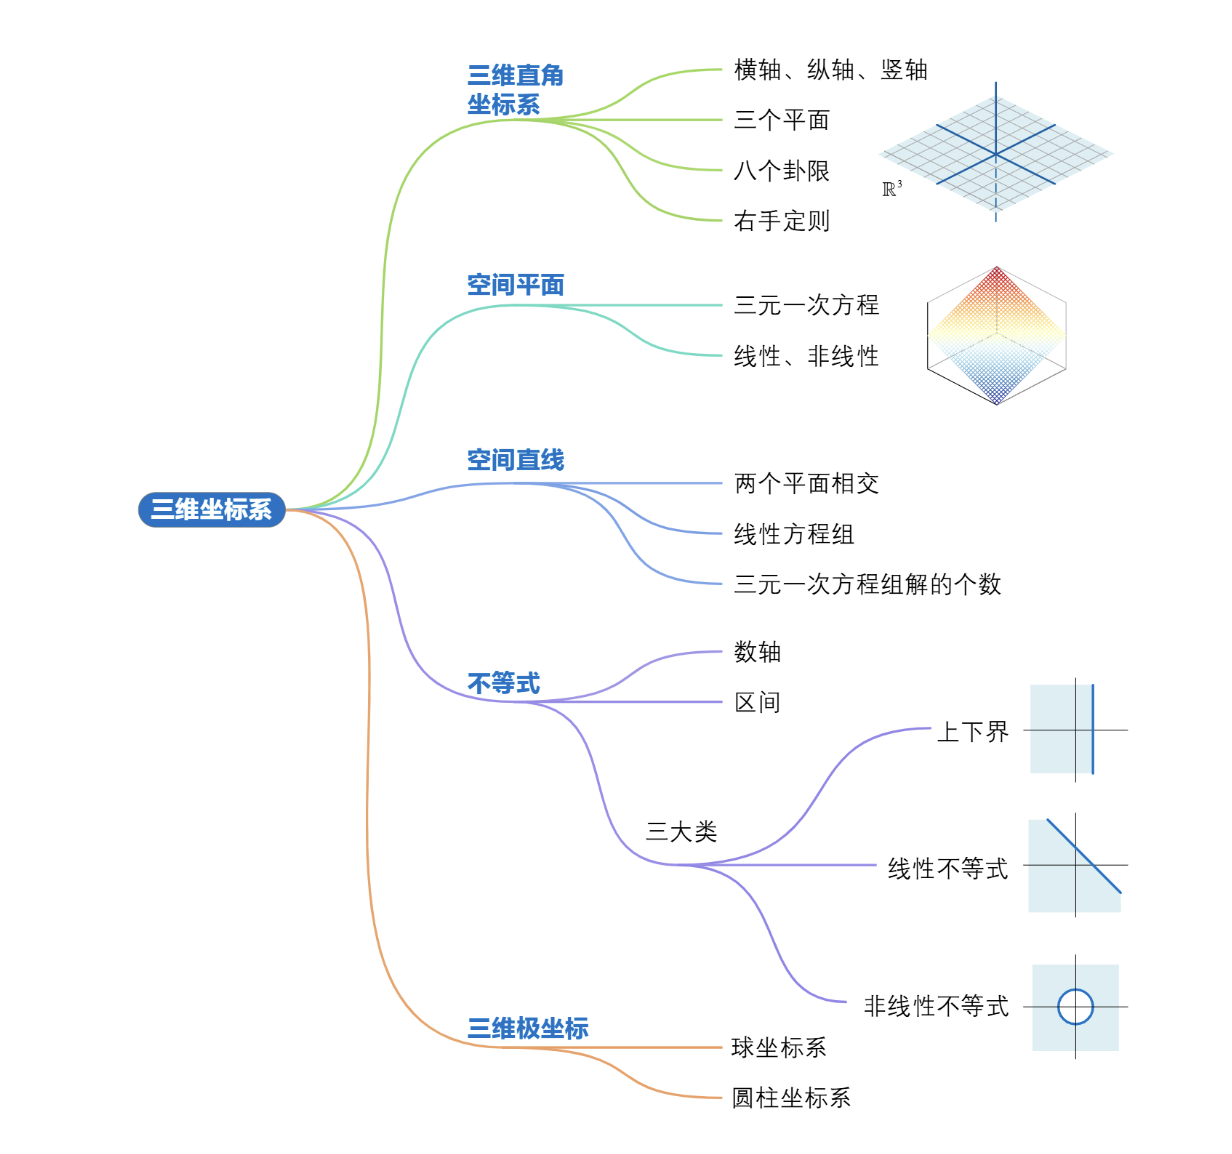

## 6.1 三维直角坐标系

三维直角坐标系有三个坐标轴 $x$ 轴或<font color="blue">横轴</font>(x-axis)，$y$ 轴或<font color="blue">纵轴</font>(y-axis)和 $z$ 轴或<font color="blue">竖轴</font>(z-axis)。

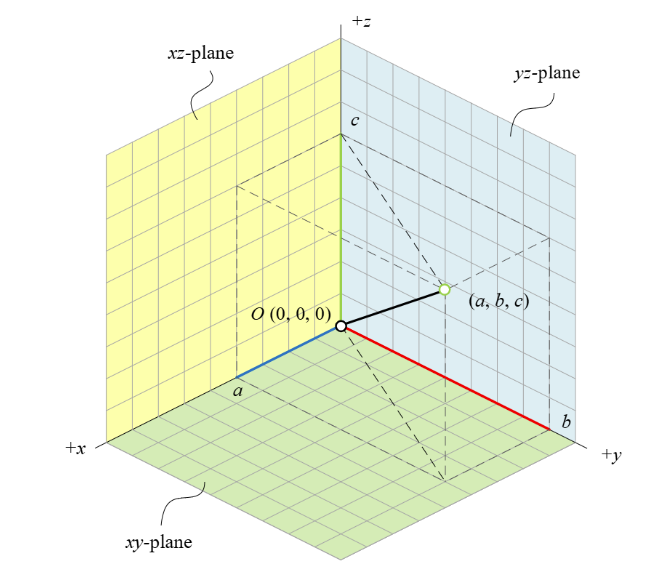

## 6.2 空间平面：三元一次方程

<font color="green">回归模型研究变量和自变量之间的关系，目的是分析预测</font>

In [14]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def plot_surf(xx, yy, zz, caption):
    
    # 正则化
    normal_plt = plt.Normalize(zz.min(), zz.max())
    colors = cm.RdYlBu_r(normal_plt(zz))

    fig = plt.figure()
    ax = fig.add_subplot(projection="3d")
    surf = ax.plot_surface(xx, yy, zz, facecolors=colors, shade=False)
    # 设置表面颜色
    surf.set_facecolor((0, 0, 0, 0))
    # 设置投影类型为正交投影 ortho，即不产生近大远小的透视效果
    ax.set_proj_type("ortho")

    if xx.min() == xx.max():
        ax.set_xlim(xx.min() - 4, xx.max() + 4)
    else:
        ax.set_xlim(xx.min(), xx.max())

    if yy.min() == yy.max():
        ax.set_ylim(yy.min() - 4, yy.max() + 4)
    else:
        ax.set_ylim(yy.min(), yy.max())

    if zz.min() == zz.max():
        ax.set_zlim(zz.min() - 4, zz.max() + 4)
    else:
        ax.set_zlim(zz.min(), zz.max())

    plt.tight_layout()

    ax.set_xlabel("$\it{x}$")
    ax.set_ylabel("$\it{y}$")
    ax.set_zlabel("$\it{z}$")
    ax.set_title(caption)
    # 设置 3D 视角 azim=-135：方位角为 -135 度 elev=30：仰角为 30 度
    ax.view_init(azim=-135, elev=30)
    ax.xaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle":":"})
    ax.yaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle":":"})
    ax.zaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle":":"})    
    plt.show()
    
num = 33
x = np.linspace(-4, 4, num)
y = np.linspace(-4, 4, num)
xx, yy = np.meshgrid(x, y)


plt.close("all")

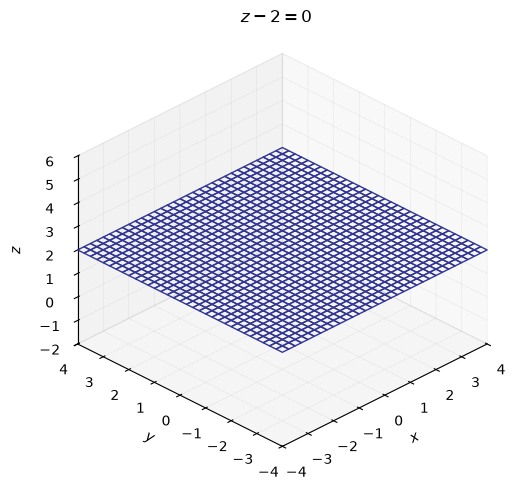

In [15]:
# z - 2 = 0
zz = 2 + xx*0
caption = "$z - 2 = 0$"
plot_surf(xx, yy, zz, caption)

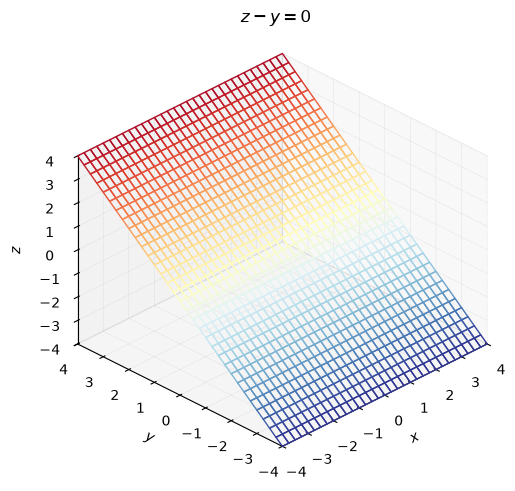

In [17]:
# y - z = 0
zz = yy
caption = "$z - y = 0$"
plot_surf(xx, yy, zz, caption)

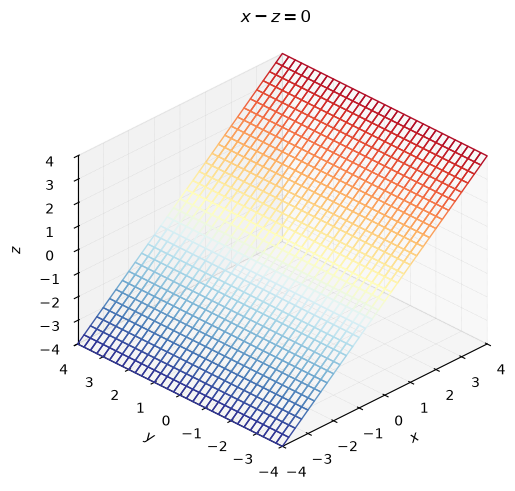

In [19]:
# x - z = 0
zz = xx
caption = "$x - z = 0$"
plot_surf(xx, yy, zz, caption)

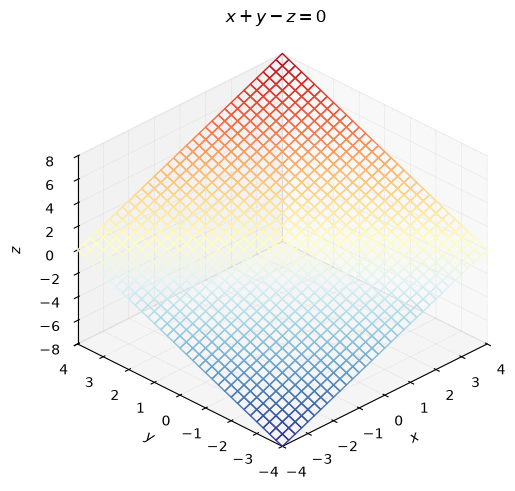

In [20]:
# x + y - z = 0
zz = xx + yy
caption = "$ x + y - z = 0$"
plot_surf(xx, yy, zz, caption)

In [21]:
# vertical mesh plot

x = np.linspace(-4, 4, num)
z = np.linspace(-4, 4, num)
xx, zz = np.meshgrid(x, z)

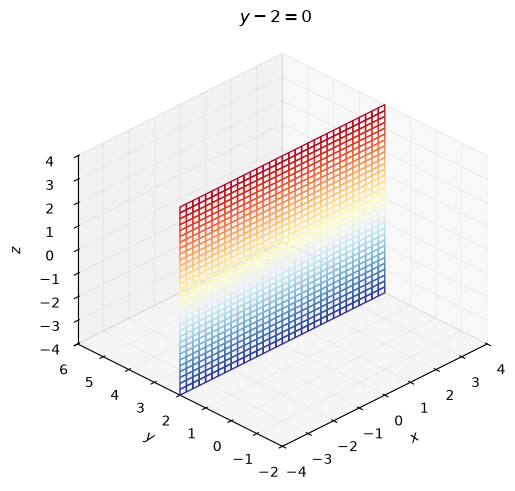

In [22]:
# y - 2 = 0
yy = 2 - xx * 0
caption = "$y - 2 = 0$"
plot_surf(xx, yy, zz, caption)

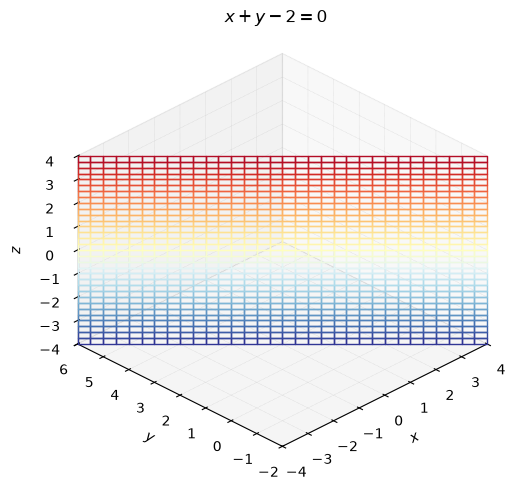

In [23]:
# x + y - 2 = 0
yy = 2 - xx
caption = "$x + y - 2 = 0$"
plot_surf(xx, yy, zz, caption)

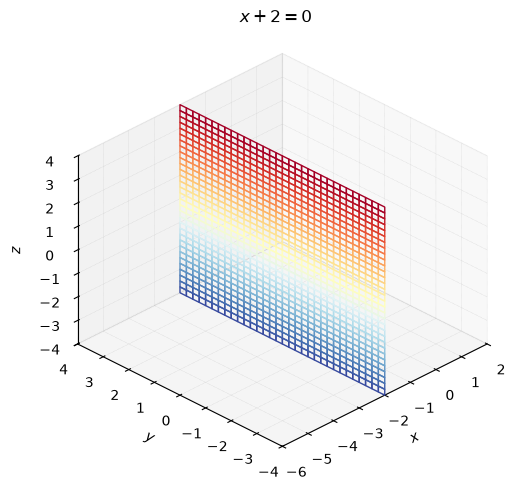

In [24]:
# x + 2 = 0
y = np.linspace(4, -4, num)
z = np.linspace(4, -4, num)
yy, zz = np.meshgrid(y, z)

xx = -2 + yy * 0
caption = "$x + 2 =0$"
plot_surf(xx, yy, zz, caption)

## 6.3 空间直线：三元一次方程组

### 三元一次方程组解的个数 

三元一次方程组解的个数几种可能性。

- 当三个平面相交于一点，方程组有且仅有一个解。

- 当三个平面相交于一条线，方程组有无数组解。无数组解还有其他情况，比如两个平面重合和第三个平面相交，再比如三个平面重合。

- 方程组无解的三种情况。三个平面平行；两个平面重合，与第三个平面平行。方程组还有其他无解的情况，比如三个平面两两相交，得到三条交线，而三条交线相互平行。

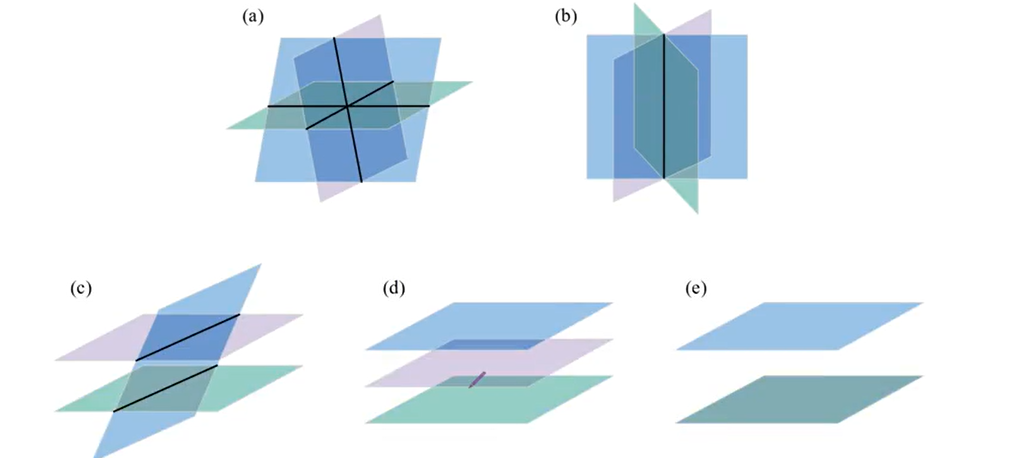

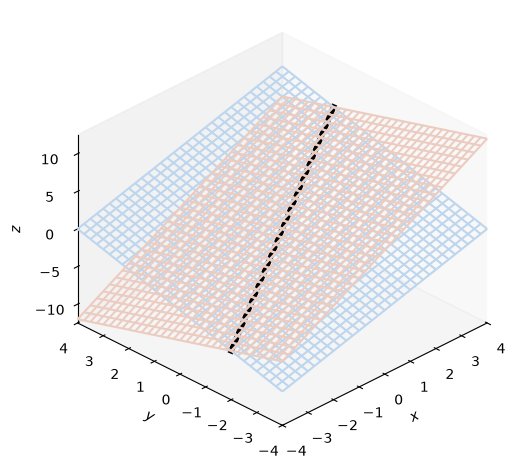

In [28]:
import math
import numpy as np
import matplotlib.pyplot as plt

num = 33
x = np.linspace(-4, 4, num)
y = np.linspace(-4, 4, num)
xx, yy = np.meshgrid(x, y)

# 定义第一个平面的z值，z = x + y
zz1 = xx + yy
# 定义第二个平面的z值，z = 2x - y
zz2 = 2 * xx - yy

fig = plt.figure()
ax = plt.axes(projection="3d")

# 计算并绘制两个平面的交线轮廓
CS = ax.contour(xx, yy, zz1 -zz2, levels=[0], colors="#339933")
# 清除上一步的轮廓以避免显示
ax.cla()

ax.plot_wireframe(xx, yy, zz1, color="#BDD6EE")
ax.plot_wireframe(xx, yy, zz2, color="#ECCCC0")

# 绘制平面交线
for i in range(0, len(CS.allsegs[0])):   # 遍历轮廓线的各个分段
    
    contour_points_x_y = CS.allsegs[0][i]  # 获取轮廓线的x和y坐标

    contour_points_z = (contour_points_x_y[:, 0] + contour_points_x_y[:, 1]) # 计算轮廓线上的z坐标

    ax.plot3D(contour_points_x_y[:, 0], contour_points_x_y[:, 1], contour_points_z, color='k', linewidth=4)
    
# 设置投影和坐标轴范围

ax.set_proj_type("ortho") # 设置投影类型为正交投影
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())

# 自动调整布局，避免重叠
plt.tight_layout()
ax.set_xlabel("$\it{x}$")
ax.set_ylabel("$\it{y}$")
ax.set_zlabel("$\it{z}$")

# 设置视角，方位角为-135度，仰角为30度
ax.view_init(azim=-135, elev=30)
ax.grid(False)

## 6.4 不等式：划定区域

### 数轴、绝对值、大小

某个数的<font color="blue">绝对值</font>(absolutevalue)是指，数轴上该数与原点的距离。

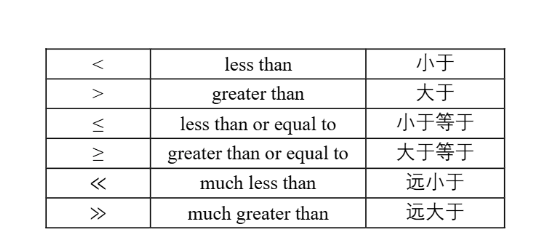

### 区间

区间两端可能<font color="blue">有界</font>(bounded)或<font color="blue">无界</font>(unbounded)，也就是区间某个可能没有端点，可以为无穷;正无穷(infinity)记作 $∞$ 或 $+∞$，负无限(negative infinity)记作 $-∞$。

### 三大类不等式

- <font color="blue">上下界</font>(lower and upper bounds)，比如 $x>2$
- <font color="blue">线性不等式</font>(linear inequalities)，比如 $x+y≤1$
- <font color="blue">非线性不等式</font>(nonlinear inequalities)，比如 $x^2+y^2≥1$

In [49]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 3D contour plot of zz
def plot_3D_f_xy(xx, yy, zz):
    fig = plt.figure(figsize=(8, 8))
    ax = plt.axes(projection="3d")

    ax.plot_wireframe(xx, yy, zz, color=[0.75, 0.75, 0.75], cmap="RdYlBu_r",
                     rstride=20, cstride=20, linewidth= 0.25)

    l_max = max(np.max(zz), -np.min(zz))
    levels = np.linspace(-1, l_max, 21)
    ax.contour(xx, yy, zz, levels=levels, cmap="RdYlBu_r")

    # plot decision boundary
    ax.contour(xx, yy, zz, levels= [0], colors=["k"])

    ax.set_proj_type("ortho")
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_zlabel("f($x_1$,$x_2$)")
    ax.view_init(azim=-120, elev=30)
    ax.grid(False)

# Wireframe plot of mask
def plot_3D_mask(xx, yy, mask):
    fig = plt.figure(figsize=(8, 8))
    ax = plt.axes(projection="3d")

    ax.plot_wireframe(xx, yy, mask, cmap="RdYlBu_r",
                     rstride=20, cstride=20, linewidth=0.25)
    ax.set_proj_type("ortho")
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_zlim(0, 1.2)
   
    plt.tight_layout()
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_zlabel("[0,1]")
    ax.set_zticks([0, 1])
    ax.view_init(azim=-120, elev=30)
    ax.grid(False)

# 2d contour plot
def plot_2D_coutour(xx, yy, zz, mask):
    rgb = [[255, 238, 255], [219, 238, 244]]  # 自定义颜色，红色和蓝色
    rgb = np.array(rgb) / 255  # 归一化RGB值
    cmap_light = ListedColormap(rgb)  # 创建颜色映射
    fig, ax = plt.subplots(figsize=(8, 8))
    l_max = max(np.max(zz), -np.min(zz))
    levels = np.linspace(-l_max, l_max, 21)
    plt.contourf(xx, yy, mask, cmap=cmap_light)
    plt.contour(xx, yy, zz, levels=levels, cmap="RdYlBu_r")

    plt.contour(xx, yy, zz, levels=[0], colors=["k"])

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    ax.grid(linestyle="--", linewidth=0.25, color=[0.5, 0.5, 0.5])
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")

num = 500
x = np.linspace(-4, 4, num)
y = np.linspace(-4, 4, num)
xx, yy = np.meshgrid(x, y)

### 上下界

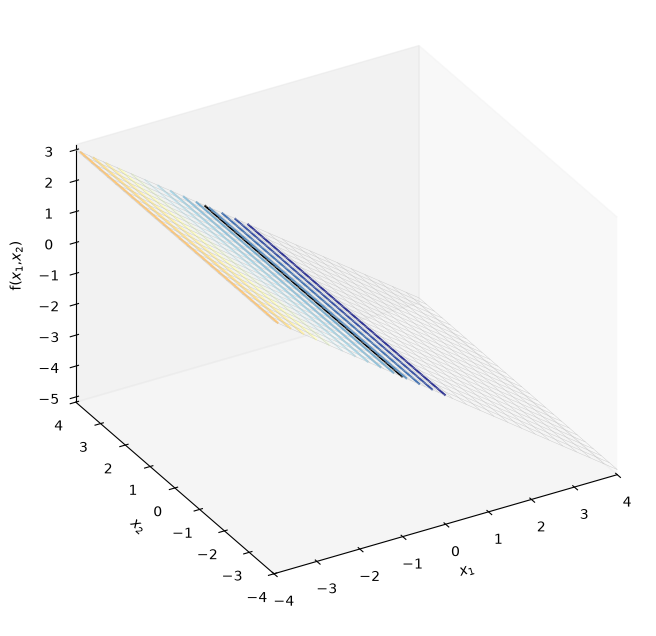

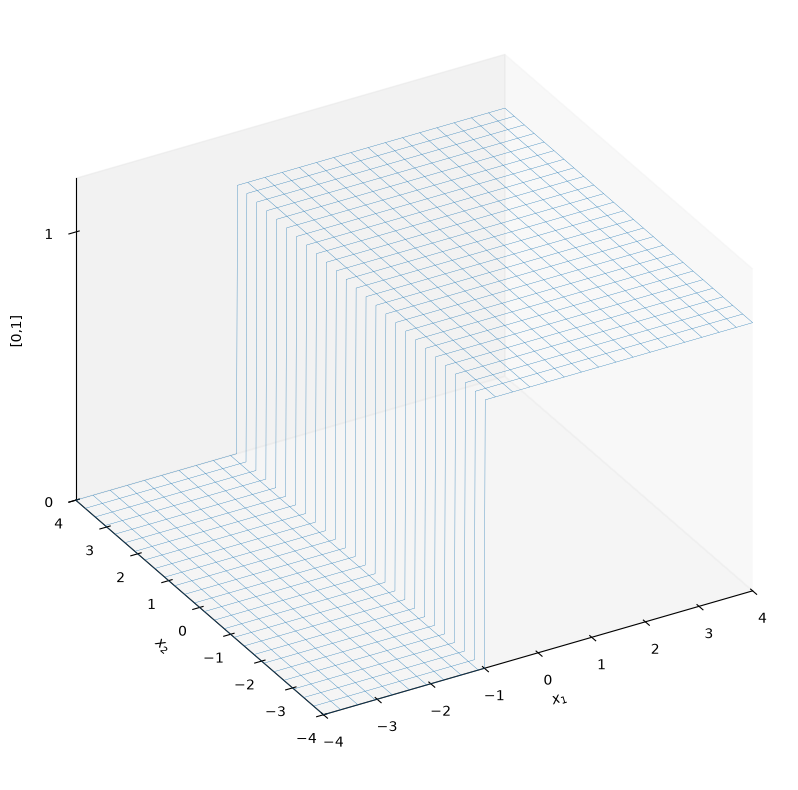

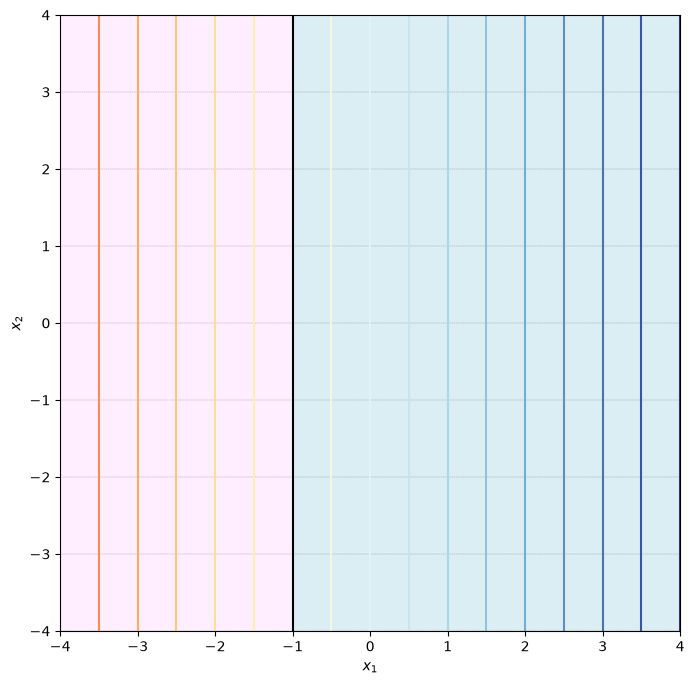

In [50]:
# 定义不等式区域 x + 1 > 0 的函数
zz = -xx - 1
mask_less_than_0 = (zz < 0) + 0
plot_3D_f_xy(xx, yy, zz)
plot_3D_mask(xx, yy, mask_less_than_0)
plot_2D_coutour(xx, yy, zz, mask_less_than_0)

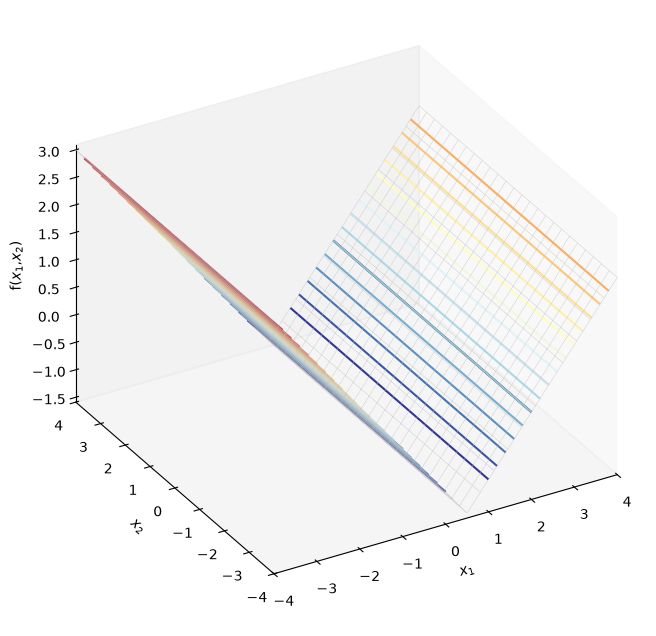

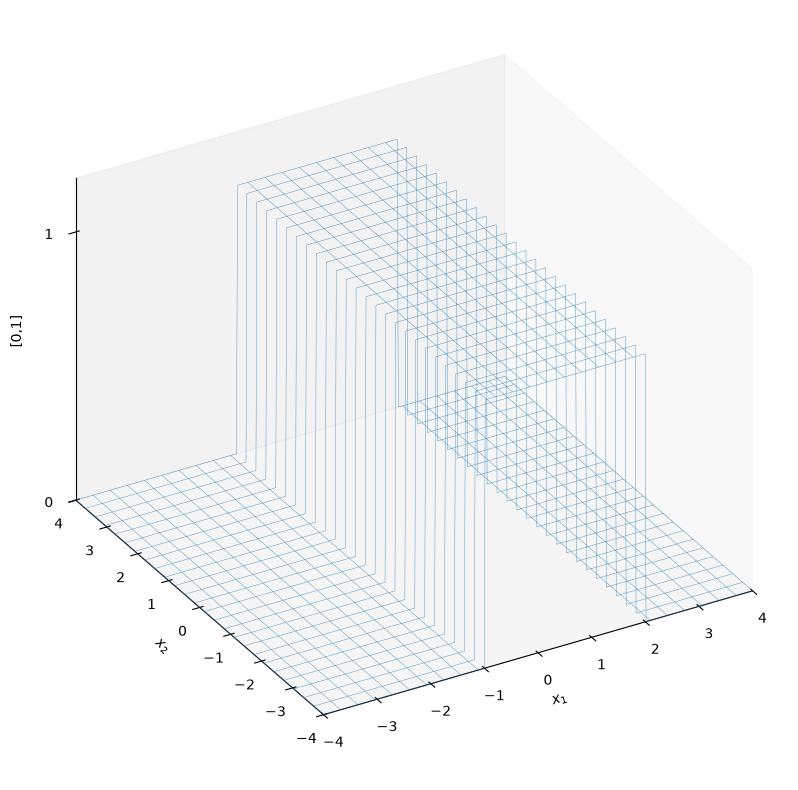

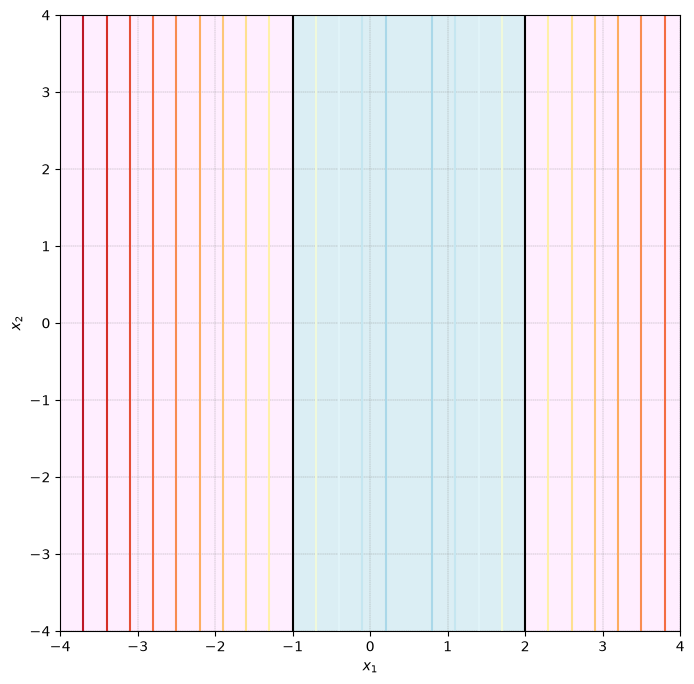

In [51]:
# 定义不等式区域-1 < x < 2
zz = np.abs(xx - 0.5) - 1.5
mask_less_than_0 = (zz < 0) + 0
plot_3D_f_xy(xx, yy, zz)
plot_3D_mask(xx, yy, mask_less_than_0)
plot_2D_coutour(xx, yy, zz, mask_less_than_0)

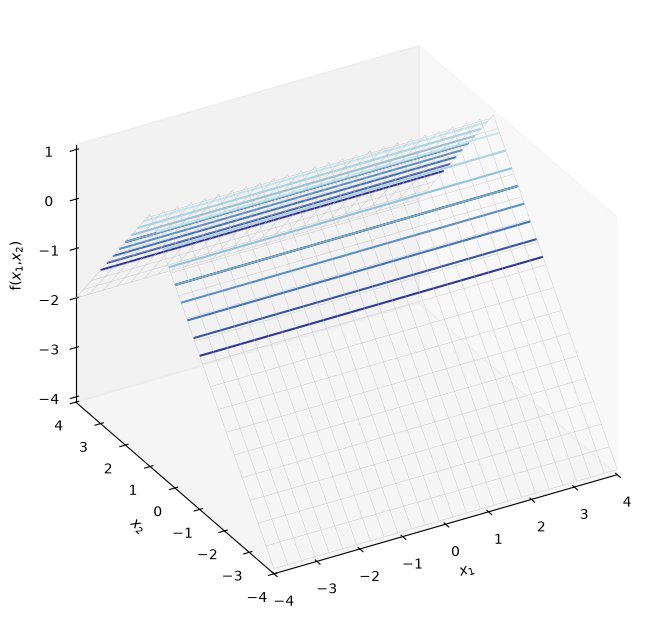

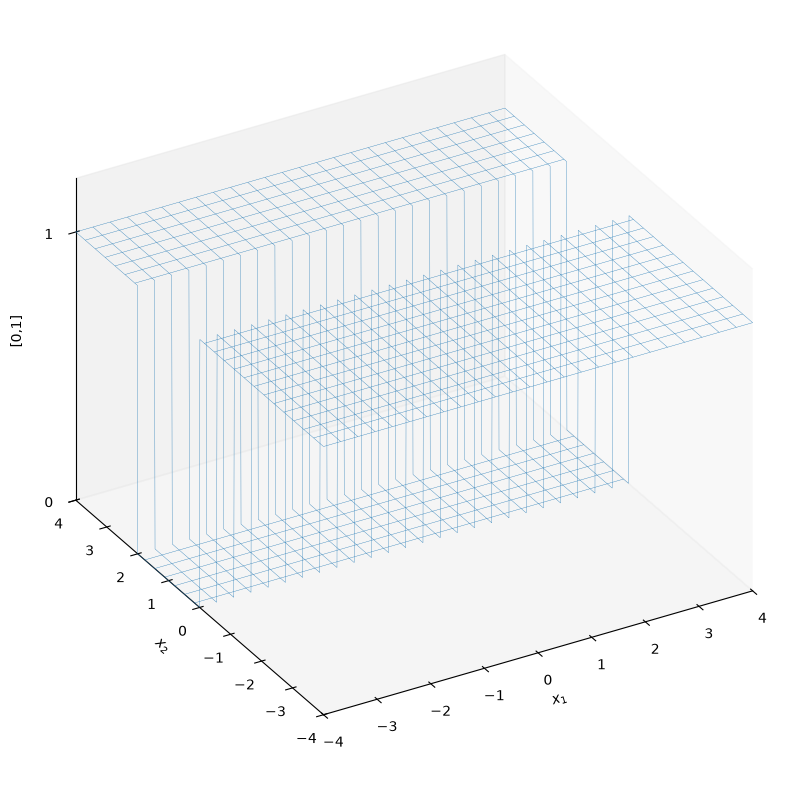

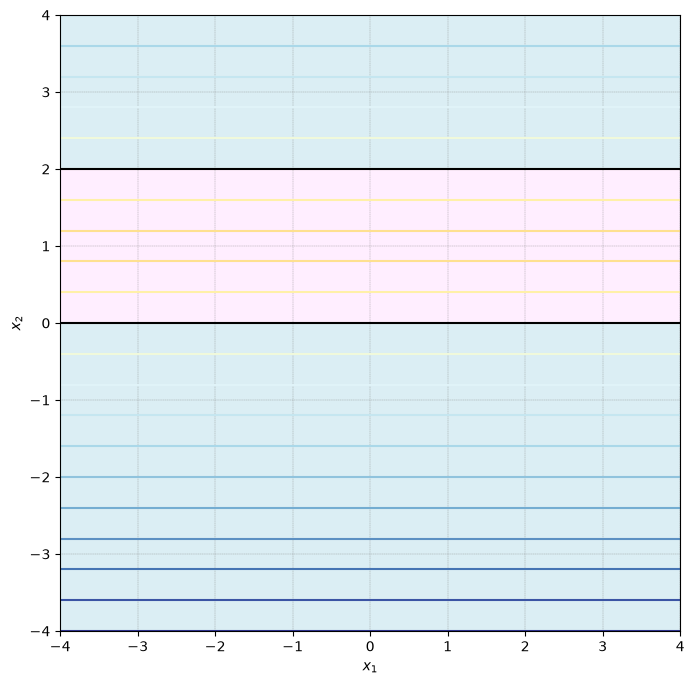

In [52]:
# 定义不等式区域 y < 0或 y > 2
zz = -np.abs(yy - 1) + 1 
mask_less_than_0 = (zz < 0) + 0
plot_3D_f_xy(xx, yy, zz)
plot_3D_mask(xx, yy, mask_less_than_0)
plot_2D_coutour(xx, yy, zz, mask_less_than_0)

### 线性不等式

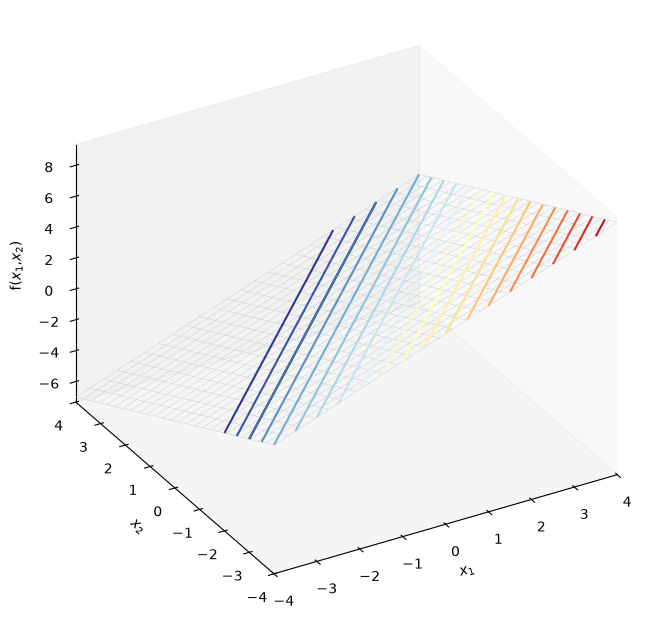

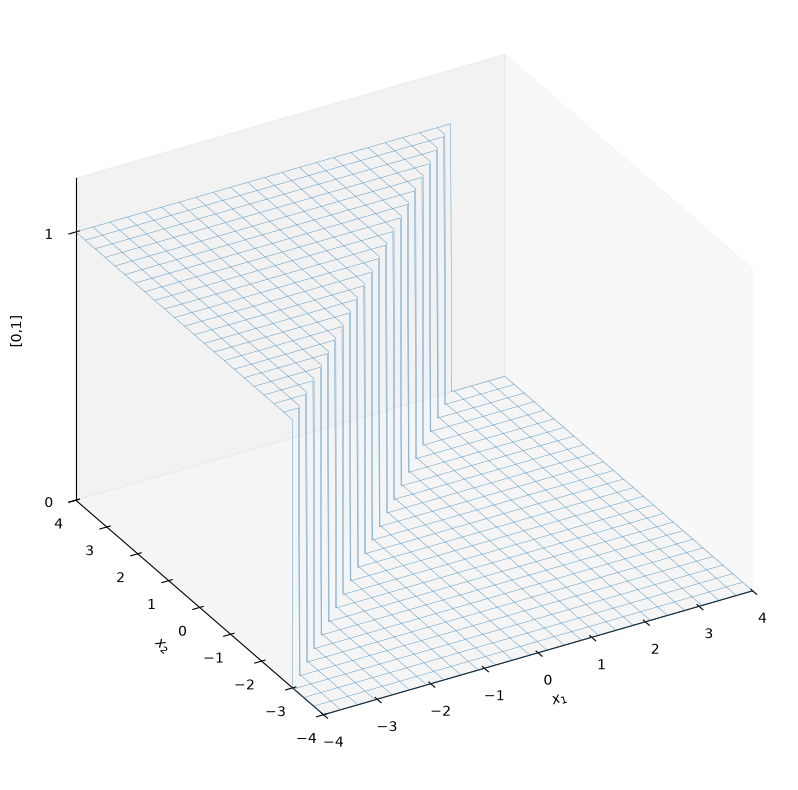

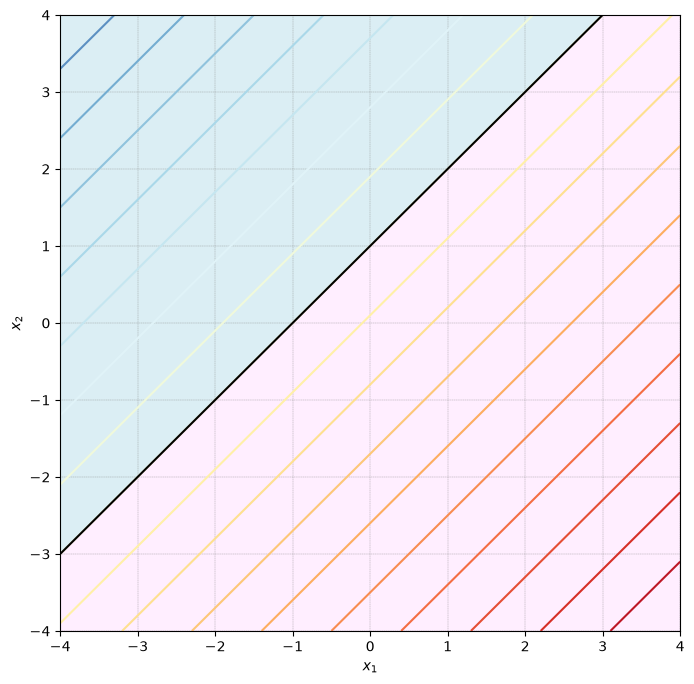

In [53]:
# 定义不等式区域 x - y + 1 < 0
zz = xx - yy + 1
mask_less_than_0 = (zz < 0) + 0
plot_3D_f_xy(xx, yy, zz)
plot_3D_mask(xx, yy, mask_less_than_0)
plot_2D_coutour(xx, yy, zz, mask_less_than_0)

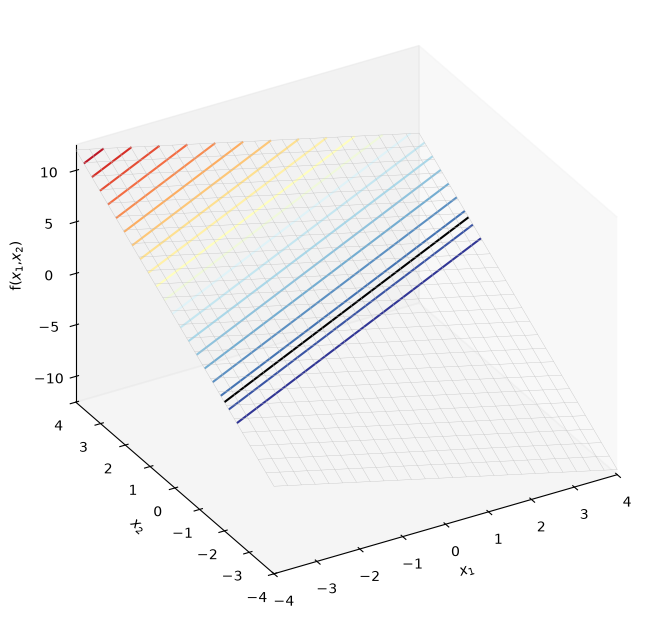

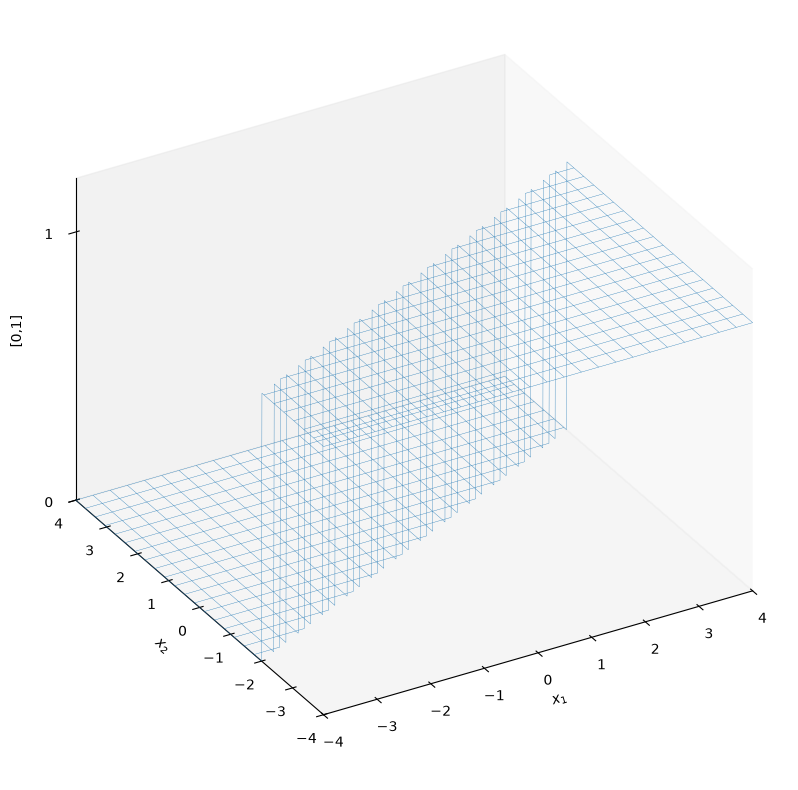

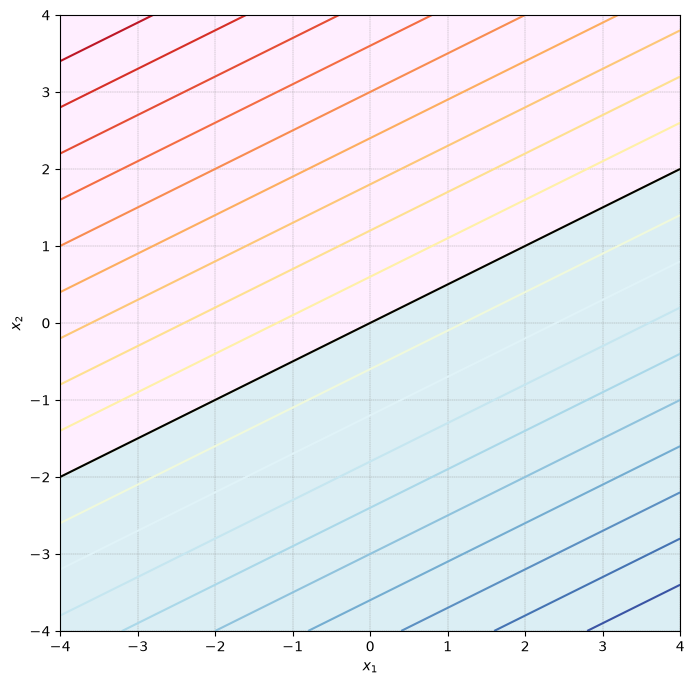

In [54]:
# 定义不等式区域 x > 2 * y
zz = -xx + yy * 2
mask_less_than_0 = (zz < 0) + 0
plot_3D_f_xy(xx, yy, zz)
plot_3D_mask(xx, yy, mask_less_than_0)
plot_2D_coutour(xx, yy, zz, mask_less_than_0)

### 非线性不等式

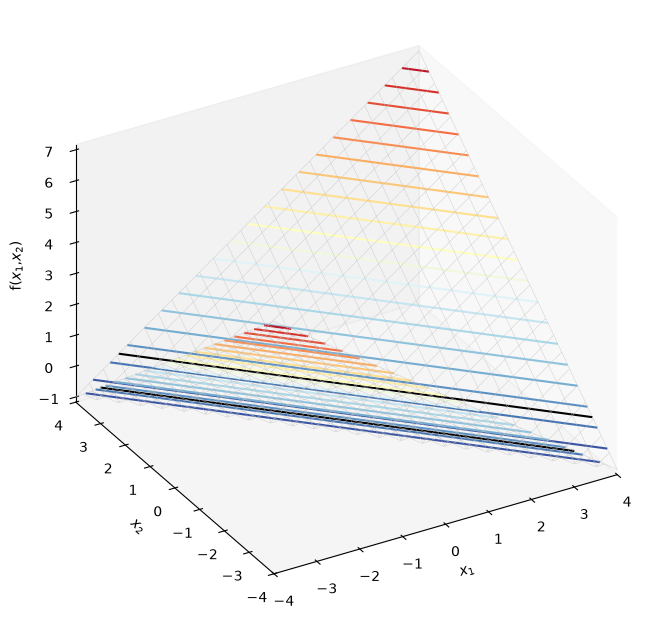

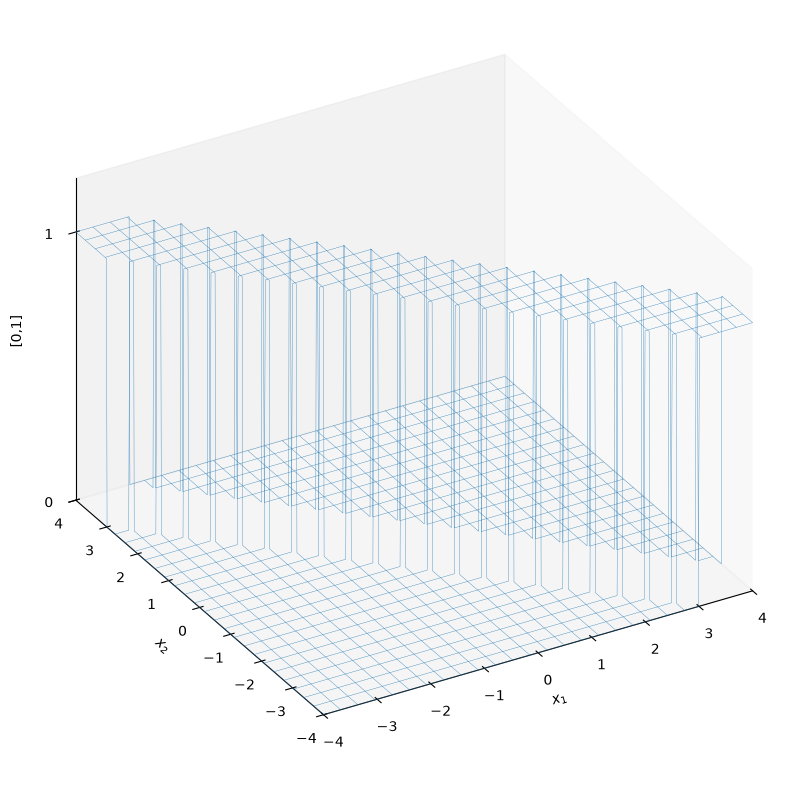

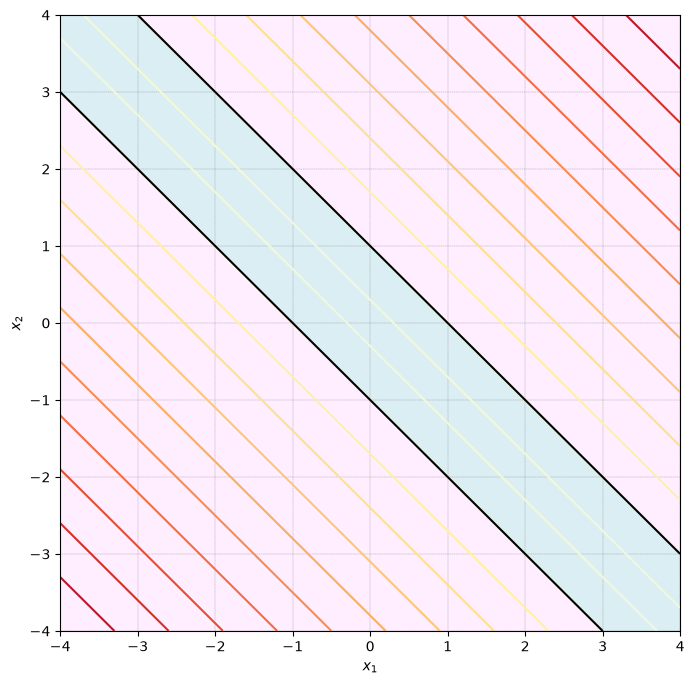

In [55]:
# 定义不等式区域 |x + y| < 1
zz = np.abs(xx + yy) - 1
mask_less_than_0 = (zz < 0) + 0
plot_3D_f_xy(xx, yy, zz)
plot_3D_mask(xx, yy, mask_less_than_0)
plot_2D_coutour(xx, yy, zz, mask_less_than_0)

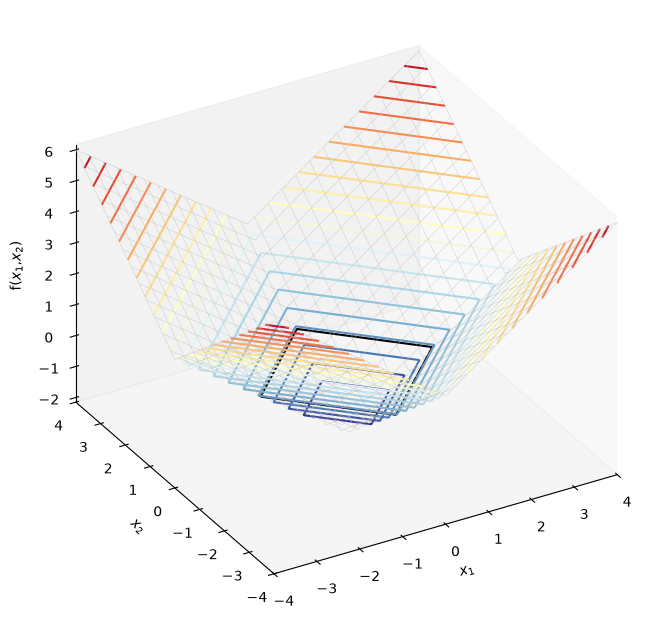

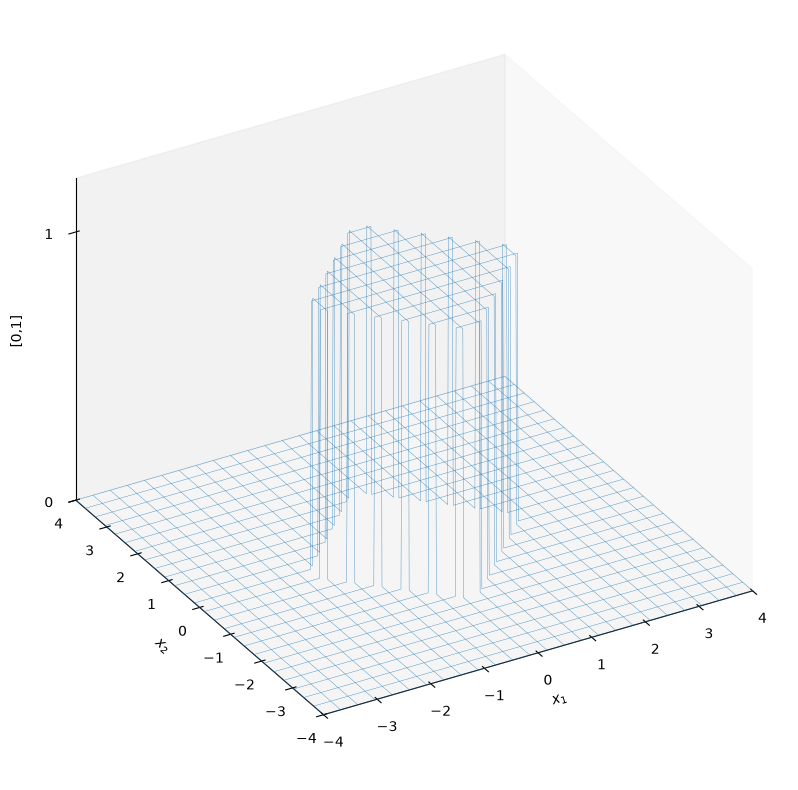

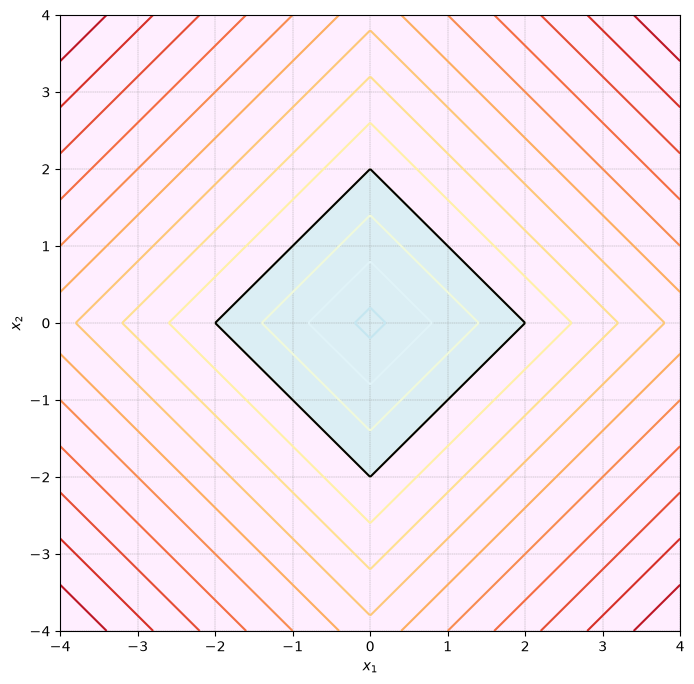

In [56]:
# 定义不等式区域 |x| + |y| < 2
zz = np.abs(xx) + np.abs(yy) - 2
mask_less_than_0 = (zz < 0) + 0
plot_3D_f_xy(xx, yy, zz)
plot_3D_mask(xx, yy, mask_less_than_0)
plot_2D_coutour(xx, yy, zz, mask_less_than_0)

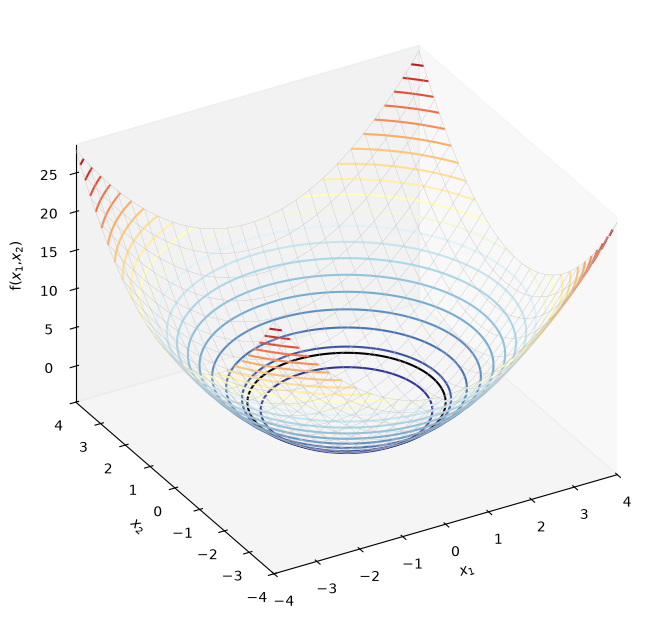

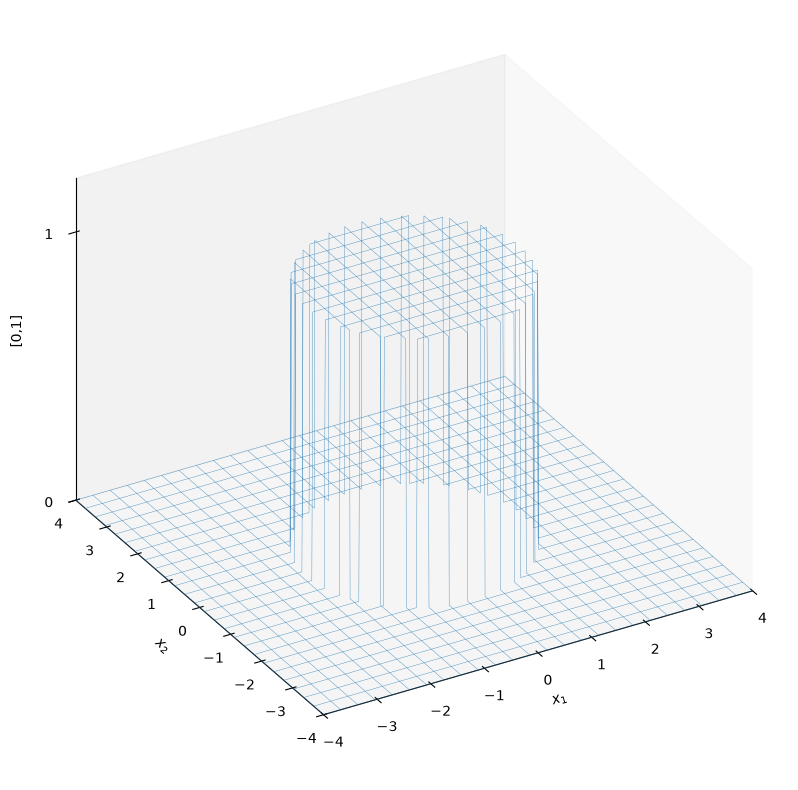

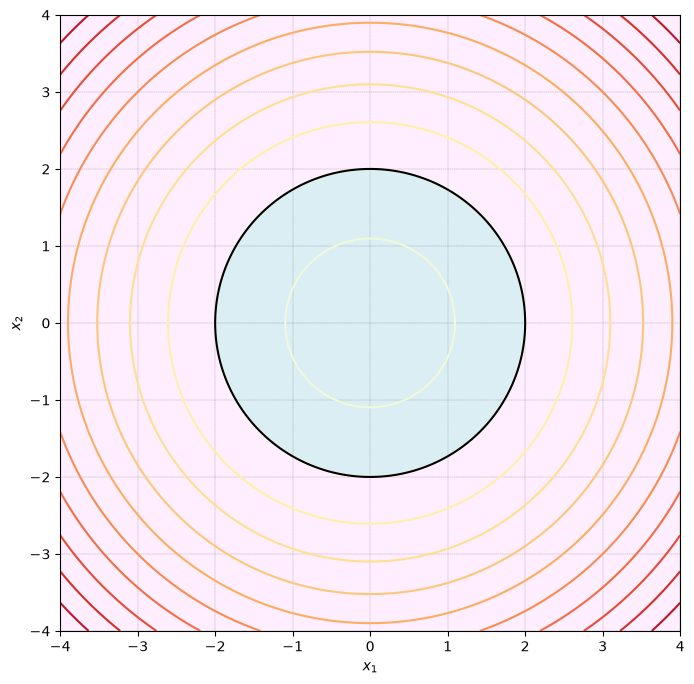

In [57]:
# 定义不等式区域 x**2 + y**2 < 4
zz = xx ** 2 + yy ** 2 - 4
mask_less_than_0 = (zz < 0) + 0
plot_3D_f_xy(xx, yy, zz)
plot_3D_mask(xx, yy, mask_less_than_0)
plot_2D_coutour(xx, yy, zz, mask_less_than_0)

## 6.5 三维极坐标

三维空间中也可以构造类似平面极坐标的坐标系统。<font color="blue">球坐标系</font>(spherical
coordinate system)和<font color="blue">圆柱坐标系</font>(cylindrical coordinate system)。

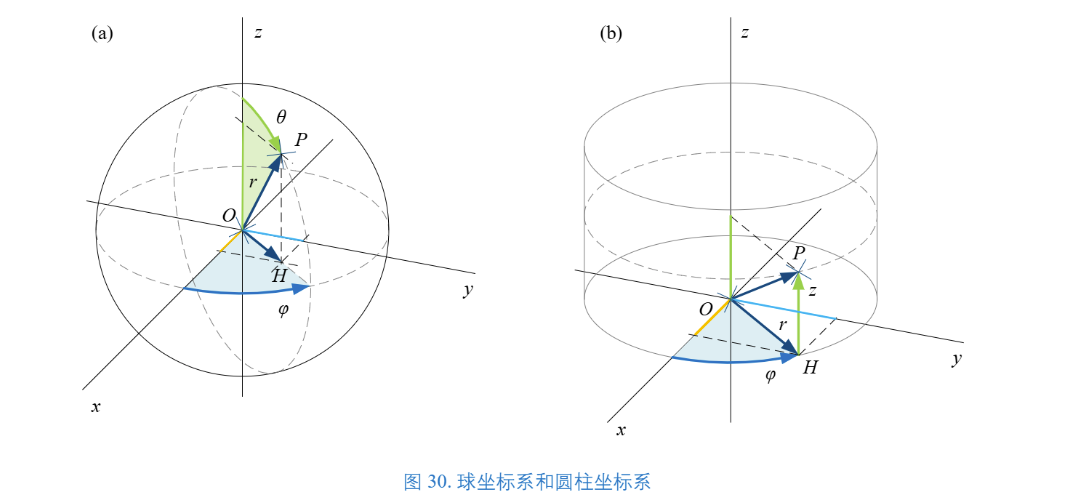

### 球坐标系

球坐标系中定位点 $P$ 用的是球坐标 $(r,\theta,\varphi)$。其中，$r$ 是 $P$ 与原点 $O$ 之间距离，也叫<font color="blue">径向距离</font>(radial distance)；$θ$ 是 $OP$ 连线和 $z$ 轴正方向夹角，叫做<font color="blue">极角</font>(polar angle)；$OP$ 连线在 $xy$ 平面投影
线为 $OH$，$\varphi$ 是 $OH$ 和 $x$ 轴正方向夹角，叫做<font color="blue">方位角</font>(azimuthangle)。

球坐标到三维直角坐标系坐标的转化关系为:

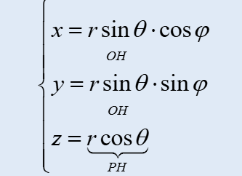

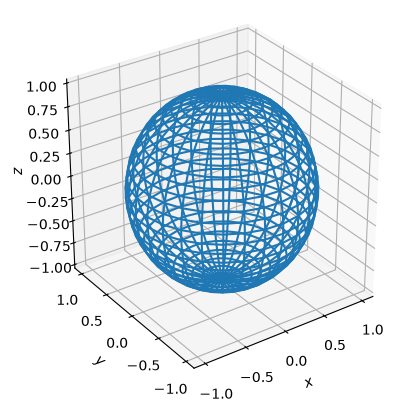

In [31]:
import numpy as np
import matplotlib.pyplot as plt

u = np.linspace(0, np.pi, 30)
v = np.linspace(0, 2 * np.pi, 30)

x = np.outer(np.sin(u), np.cos(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.cos(u), np.ones_like(v))

fig = plt.figure()
ax = plt.axes(projection="3d")
ax.set_aspect("equal")

ax.plot_wireframe(x, y, z)
ax.set_xlabel("$\it{x}$")
ax.set_ylabel("$\it{y}$")
ax.set_zlabel("$\it{z}$")
ax.view_init(azim=-125, elev=30)

### 圆柱坐标系

从圆柱坐标到三维直角坐标系坐标转化关系为:

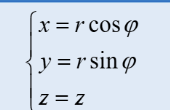

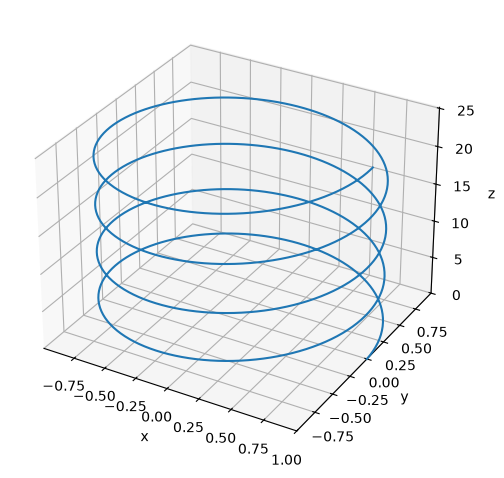

In [33]:
from sympy import *
from sympy.plotting import plot3d_parametric_line
import math

t = symbols("t")

x1 = cos(t)
x2 = sin(t)
x3 = t

plot3d_parametric_line(x1, x2, x3, (t, 0, 8 * math.pi))